# KISAAN AI — Binary Disease Classifier v3
### Healthy vs At_Risk across 49 crops using XGBoost
**Output:** `crop_disease_model.pkl` + `crop_name_encoder.pkl` + `disease_label_encoder.pkl`

Replaces the old `crop_recommendation_v2.ipynb`. Same pkl filenames so `app.py` needs zero changes.

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print('Libraries loaded ✅')

Libraries loaded ✅


## Step 1 — Crop Profiles
Each crop has a HEALTHY range and AT_RISK range for all 7 sensor features.
At-risk = environmental conditions that favour disease outbreak.

In [2]:
# Format: crop_name → {healthy: {feature: (low,high)}, atrisk: {feature: (low,high)}}
# 49 crops covering all crops in DISEASE_CROPS map in app.py

CROP_PROFILES = {
    'rice':        {'healthy': dict(N=(50,110), P=(25,70),  K=(20,65),  temp=(20,34), rh=(60,80),  rain=(100,280), ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,55),   P=(5,35),   K=(5,30),   temp=(18,32), rh=(78,99),  rain=(200,440), ph=(4.0,6.0))},
    'maize':       {'healthy': dict(N=(50,110), P=(28,72),  K=(22,68),  temp=(18,34), rh=(42,75),  rain=(70,200),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,60),   P=(5,38),   K=(5,35),   temp=(13,28), rh=(68,98),  rain=(160,395), ph=(4.0,6.0))},
    'wheat':       {'healthy': dict(N=(70,138), P=(25,72),  K=(22,68),  temp=(8,26),  rh=(32,65),  rain=(35,130),  ph=(5.8,7.8)),
                    'atrisk':  dict(N=(8,62),   P=(5,35),   K=(5,32),   temp=(3,20),  rh=(65,98),  rain=(90,275),  ph=(4.2,6.2))},
    'cotton':      {'healthy': dict(N=(75,158), P=(28,74),  K=(38,88),  temp=(20,38), rh=(30,68),  rain=(42,155),  ph=(6.2,8.0)),
                    'atrisk':  dict(N=(12,78),  P=(5,32),   K=(5,36),   temp=(11,33), rh=(65,99),  rain=(125,328), ph=(4.0,6.2))},
    'banana':      {'healthy': dict(N=(65,128), P=(50,108), K=(28,74),  temp=(22,38), rh=(60,88),  rain=(125,295), ph=(5.2,7.0)),
                    'atrisk':  dict(N=(8,65),   P=(8,45),   K=(5,28),   temp=(15,32), rh=(75,99),  rain=(228,462), ph=(4.0,5.6))},
    'mango':       {'healthy': dict(N=(8,35),   P=(10,48),  K=(10,52),  temp=(22,42), rh=(30,72),  rain=(40,205),  ph=(4.9,6.7)),
                    'atrisk':  dict(N=(5,15),   P=(5,18),   K=(5,18),   temp=(15,40), rh=(68,98),  rain=(155,392), ph=(3.8,5.4))},
    'coffee':      {'healthy': dict(N=(65,128), P=(10,50),  K=(10,52),  temp=(13,30), rh=(55,88),  rain=(85,255),  ph=(5.7,7.0)),
                    'atrisk':  dict(N=(12,68),  P=(5,18),   K=(5,18),   temp=(14,32), rh=(75,99),  rain=(195,415), ph=(4.0,6.0))},
    'chickpea':    {'healthy': dict(N=(15,62),  P=(42,94),  K=(52,108), temp=(9,30),  rh=(20,58),  rain=(18,118),  ph=(6.2,8.0)),
                    'atrisk':  dict(N=(5,22),   P=(5,28),   K=(8,48),   temp=(3,28),  rh=(62,98),  rain=(88,272),  ph=(4.0,6.4))},
    'kidneybeans': {'healthy': dict(N=(15,55),  P=(35,80),  K=(15,55),  temp=(15,30), rh=(40,75),  rain=(60,180),  ph=(5.8,7.5)),
                    'atrisk':  dict(N=(5,25),   P=(5,30),   K=(5,22),   temp=(10,32), rh=(70,98),  rain=(130,320), ph=(4.2,6.0))},
    'pigeonpeas':  {'healthy': dict(N=(10,50),  P=(30,75),  K=(15,55),  temp=(20,35), rh=(30,65),  rain=(60,200),  ph=(5.5,7.5)),
                    'atrisk':  dict(N=(5,20),   P=(5,28),   K=(5,20),   temp=(15,38), rh=(68,98),  rain=(120,350), ph=(4.0,6.0))},
    'mothbeans':   {'healthy': dict(N=(10,45),  P=(25,65),  K=(15,50),  temp=(22,40), rh=(20,55),  rain=(20,100),  ph=(5.5,7.5)),
                    'atrisk':  dict(N=(5,18),   P=(5,22),   K=(5,18),   temp=(18,42), rh=(60,95),  rain=(80,250),  ph=(4.2,6.0))},
    'mungbean':    {'healthy': dict(N=(15,55),  P=(30,72),  K=(15,55),  temp=(22,38), rh=(35,70),  rain=(50,180),  ph=(5.8,7.5)),
                    'atrisk':  dict(N=(5,22),   P=(5,28),   K=(5,22),   temp=(18,40), rh=(68,98),  rain=(120,320), ph=(4.2,6.2))},
    'blackgram':   {'healthy': dict(N=(15,55),  P=(30,72),  K=(15,55),  temp=(22,38), rh=(35,70),  rain=(50,180),  ph=(5.8,7.5)),
                    'atrisk':  dict(N=(5,22),   P=(5,28),   K=(5,22),   temp=(18,42), rh=(70,98),  rain=(120,320), ph=(4.2,6.2))},
    'lentil':      {'healthy': dict(N=(8,34),   P=(42,96),  K=(8,36),   temp=(6,26),  rh=(20,55),  rain=(15,108),  ph=(6.2,8.0)),
                    'atrisk':  dict(N=(5,16),   P=(5,35),   K=(5,14),   temp=(4,28),  rh=(60,96),  rain=(75,265),  ph=(4.2,6.2))},
    'pomegranate': {'healthy': dict(N=(15,55),  P=(10,48),  K=(25,72),  temp=(18,38), rh=(25,65),  rain=(30,155),  ph=(5.5,7.5)),
                    'atrisk':  dict(N=(5,22),   P=(5,18),   K=(8,28),   temp=(14,40), rh=(62,96),  rain=(100,320), ph=(4.0,6.0))},
    'grapes':      {'healthy': dict(N=(15,55),  P=(10,45),  K=(35,88),  temp=(12,30), rh=(35,72),  rain=(55,180),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,22),   P=(5,18),   K=(10,38),  temp=(8,32),  rh=(68,98),  rain=(120,320), ph=(4.0,6.0))},
    'watermelon':  {'healthy': dict(N=(35,85),  P=(20,60),  K=(25,72),  temp=(22,38), rh=(35,72),  rain=(40,155),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(8,38),   P=(5,22),   K=(8,28),   temp=(18,42), rh=(68,98),  rain=(110,300), ph=(4.0,6.0))},
    'muskmelon':   {'healthy': dict(N=(30,80),  P=(18,58),  K=(22,68),  temp=(22,38), rh=(32,68),  rain=(35,145),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(8,35),   P=(5,20),   K=(8,26),   temp=(18,42), rh=(66,98),  rain=(100,290), ph=(4.0,6.0))},
    'apple':       {'healthy': dict(N=(18,62),  P=(12,48),  K=(25,78),  temp=(5,22),  rh=(38,72),  rain=(55,185),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,25),   P=(5,18),   K=(8,30),   temp=(2,24),  rh=(66,98),  rain=(115,350), ph=(4.0,6.0))},
    'orange':      {'healthy': dict(N=(18,62),  P=(10,45),  K=(12,52),  temp=(15,35), rh=(40,78),  rain=(65,215),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,25),   P=(5,18),   K=(5,22),   temp=(12,38), rh=(68,98),  rain=(140,380), ph=(4.0,6.0))},
    'papaya':      {'healthy': dict(N=(45,108), P=(30,75),  K=(30,78),  temp=(22,38), rh=(55,85),  rain=(80,240),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(8,48),   P=(5,28),   K=(8,32),   temp=(18,42), rh=(72,99),  rain=(160,420), ph=(4.0,6.0))},
    'coconut':     {'healthy': dict(N=(45,108), P=(18,58),  K=(45,108), temp=(22,38), rh=(60,90),  rain=(130,320), ph=(5.5,7.5)),
                    'atrisk':  dict(N=(8,48),   P=(5,22),   K=(12,48),  temp=(18,42), rh=(75,99),  rain=(200,480), ph=(4.0,6.2))},
    'jute':        {'healthy': dict(N=(55,115), P=(22,65),  K=(22,65),  temp=(22,38), rh=(60,90),  rain=(120,320), ph=(5.5,7.5)),
                    'atrisk':  dict(N=(10,55),  P=(5,25),   K=(5,28),   temp=(18,42), rh=(75,99),  rain=(200,500), ph=(4.0,6.2))},
    'potato':      {'healthy': dict(N=(62,132), P=(25,74),  K=(50,108), temp=(9,24),  rh=(40,75),  rain=(50,185),  ph=(4.9,6.7)),
                    'atrisk':  dict(N=(8,65),   P=(5,32),   K=(8,45),   temp=(5,23),  rh=(72,99),  rain=(145,345), ph=(3.8,5.6))},
    'tomato':      {'healthy': dict(N=(55,128), P=(28,74),  K=(42,98),  temp=(17,32), rh=(40,73),  rain=(42,165),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(8,65),   P=(5,32),   K=(8,42),   temp=(9,33),  rh=(70,99),  rain=(120,322), ph=(4.0,5.8))},
    'sugarcane':   {'healthy': dict(N=(75,155), P=(25,70),  K=(28,74),  temp=(20,38), rh=(55,88),  rain=(90,255),  ph=(5.7,7.5)),
                    'atrisk':  dict(N=(12,78),  P=(5,32),   K=(5,36),   temp=(15,38), rh=(78,99),  rain=(200,408), ph=(4.0,6.0))},
    'soybean':     {'healthy': dict(N=(15,68),  P=(40,96),  K=(8,44),   temp=(16,33), rh=(46,78),  rain=(70,205),  ph=(5.7,7.3)),
                    'atrisk':  dict(N=(5,28),   P=(5,42),   K=(5,18),   temp=(9,33),  rh=(70,99),  rain=(158,345), ph=(4.0,6.0))},
    'groundnut':   {'healthy': dict(N=(10,42),  P=(32,78),  K=(10,42),  temp=(20,36), rh=(36,72),  rain=(50,185),  ph=(5.5,7.0)),
                    'atrisk':  dict(N=(5,18),   P=(5,32),   K=(5,16),   temp=(24,45), rh=(66,98),  rain=(138,335), ph=(4.0,5.8))},
    'cassava':     {'healthy': dict(N=(10,55),  P=(10,44),  K=(22,68),  temp=(20,36), rh=(46,80),  rain=(65,205),  ph=(4.9,6.7)),
                    'atrisk':  dict(N=(5,20),   P=(5,16),   K=(5,22),   temp=(13,33), rh=(70,99),  rain=(155,365), ph=(3.8,5.4))},
    'barley':      {'healthy': dict(N=(38,100), P=(20,64),  K=(16,62),  temp=(6,24),  rh=(26,62),  rain=(25,110),  ph=(5.7,7.8)),
                    'atrisk':  dict(N=(5,52),   P=(5,30),   K=(5,30),   temp=(2,22),  rh=(60,98),  rain=(85,255),  ph=(4.2,6.2))},
    'sorghum':     {'healthy': dict(N=(35,90),  P=(16,58),  K=(20,62),  temp=(20,38), rh=(32,68),  rain=(35,155),  ph=(5.2,7.5)),
                    'atrisk':  dict(N=(5,45),   P=(5,28),   K=(5,28),   temp=(15,33), rh=(65,98),  rain=(120,308), ph=(4.0,5.8))},
    'pea':         {'healthy': dict(N=(12,50),  P=(38,88),  K=(18,62),  temp=(8,24),  rh=(30,65),  rain=(30,125),  ph=(6.0,7.8)),
                    'atrisk':  dict(N=(5,22),   P=(5,35),   K=(5,25),   temp=(4,26),  rh=(65,98),  rain=(90,285),  ph=(4.5,6.2))},
    'bean':        {'healthy': dict(N=(15,55),  P=(35,80),  K=(15,55),  temp=(15,28), rh=(40,75),  rain=(60,180),  ph=(5.8,7.5)),
                    'atrisk':  dict(N=(5,25),   P=(5,30),   K=(5,22),   temp=(10,30), rh=(70,98),  rain=(130,320), ph=(4.2,6.0))},
    'sweetpotato': {'healthy': dict(N=(55,115), P=(25,68),  K=(45,105), temp=(18,32), rh=(55,85),  rain=(75,220),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(10,55),  P=(5,28),   K=(12,48),  temp=(14,36), rh=(70,98),  rain=(150,380), ph=(4.0,6.0))},
    'yam':         {'healthy': dict(N=(45,105), P=(22,65),  K=(38,95),  temp=(22,35), rh=(55,88),  rain=(100,280), ph=(5.5,7.2)),
                    'atrisk':  dict(N=(8,48),   P=(5,25),   K=(10,42),  temp=(18,38), rh=(72,99),  rain=(180,420), ph=(4.0,6.0))},
    'rapeseed':    {'healthy': dict(N=(65,135), P=(25,68),  K=(22,65),  temp=(5,22),  rh=(35,68),  rain=(35,145),  ph=(5.8,7.5)),
                    'atrisk':  dict(N=(10,65),  P=(5,28),   K=(5,28),   temp=(2,24),  rh=(65,98),  rain=(95,298),  ph=(4.2,6.2))},
    'sugarbeet':   {'healthy': dict(N=(85,165), P=(28,72),  K=(95,195), temp=(12,25), rh=(38,72),  rain=(50,185),  ph=(6.0,8.0)),
                    'atrisk':  dict(N=(12,85),  P=(5,30),   K=(20,95),  temp=(8,28),  rh=(65,98),  rain=(120,340), ph=(4.5,6.5))},
    'peach':       {'healthy': dict(N=(18,58),  P=(12,48),  K=(22,72),  temp=(8,25),  rh=(38,70),  rain=(55,175),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,25),   P=(5,18),   K=(8,30),   temp=(4,28),  rh=(66,98),  rain=(110,340), ph=(4.0,6.0))},
    'cherry':      {'healthy': dict(N=(18,55),  P=(12,45),  K=(22,68),  temp=(5,22),  rh=(38,70),  rain=(55,170),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,22),   P=(5,18),   K=(8,28),   temp=(2,24),  rh=(65,98),  rain=(108,332), ph=(4.0,6.0))},
    'strawberry':  {'healthy': dict(N=(18,55),  P=(15,50),  K=(22,68),  temp=(10,25), rh=(38,70),  rain=(45,165),  ph=(5.5,7.0)),
                    'atrisk':  dict(N=(5,22),   P=(5,20),   K=(8,28),   temp=(6,28),  rh=(65,98),  rain=(100,320), ph=(4.0,6.0))},
    'blueberry':   {'healthy': dict(N=(15,48),  P=(8,38),   K=(15,52),  temp=(8,24),  rh=(42,75),  rain=(55,185),  ph=(4.5,5.5)),
                    'atrisk':  dict(N=(5,18),   P=(5,15),   K=(5,22),   temp=(4,26),  rh=(68,98),  rain=(110,340), ph=(3.8,5.0))},
    'raspberry':   {'healthy': dict(N=(15,52),  P=(10,42),  K=(18,58),  temp=(8,24),  rh=(38,72),  rain=(55,175),  ph=(5.5,7.0)),
                    'atrisk':  dict(N=(5,20),   P=(5,16),   K=(5,24),   temp=(4,26),  rh=(65,98),  rain=(108,330), ph=(4.0,6.0))},
    'squash':      {'healthy': dict(N=(35,85),  P=(18,58),  K=(22,68),  temp=(18,35), rh=(38,72),  rain=(40,155),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(8,38),   P=(5,22),   K=(8,28),   temp=(15,38), rh=(66,98),  rain=(100,295), ph=(4.0,6.0))},
    'bellpepper':  {'healthy': dict(N=(45,105), P=(22,65),  K=(35,88),  temp=(18,32), rh=(42,75),  rain=(45,165),  ph=(5.8,7.2)),
                    'atrisk':  dict(N=(8,48),   P=(5,25),   K=(8,38),   temp=(14,35), rh=(68,98),  rain=(110,308), ph=(4.2,6.0))},
    'corn':        {'healthy': dict(N=(50,110), P=(28,72),  K=(22,68),  temp=(18,34), rh=(42,75),  rain=(70,200),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,60),   P=(5,38),   K=(5,35),   temp=(13,28), rh=(68,98),  rain=(160,395), ph=(4.0,6.0))},
    'grape':       {'healthy': dict(N=(15,55),  P=(10,45),  K=(35,88),  temp=(12,30), rh=(35,72),  rain=(55,180),  ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,22),   P=(5,18),   K=(10,38),  temp=(8,32),  rh=(68,98),  rain=(120,320), ph=(4.0,6.0))},
    'pepper':      {'healthy': dict(N=(45,105), P=(22,65),  K=(35,88),  temp=(18,32), rh=(42,75),  rain=(45,165),  ph=(5.8,7.2)),
                    'atrisk':  dict(N=(8,48),   P=(5,25),   K=(8,38),   temp=(14,35), rh=(68,98),  rain=(110,308), ph=(4.2,6.0))},
    'paddy':       {'healthy': dict(N=(50,110), P=(25,70),  K=(20,65),  temp=(20,34), rh=(60,80),  rain=(100,280), ph=(5.5,7.2)),
                    'atrisk':  dict(N=(5,55),   P=(5,35),   K=(5,30),   temp=(18,32), rh=(78,99),  rain=(200,440), ph=(4.0,6.0))},
}

CROPS = list(CROP_PROFILES.keys())
print(f'Total crops: {len(CROPS)}')
print('Crops:', CROPS)

Total crops: 48
Crops: ['rice', 'maize', 'wheat', 'cotton', 'banana', 'mango', 'coffee', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut', 'jute', 'potato', 'tomato', 'sugarcane', 'soybean', 'groundnut', 'cassava', 'barley', 'sorghum', 'pea', 'bean', 'sweetpotato', 'yam', 'rapeseed', 'sugarbeet', 'peach', 'cherry', 'strawberry', 'blueberry', 'raspberry', 'squash', 'bellpepper', 'corn', 'grape', 'pepper', 'paddy']


## Step 2 — Generate Synthetic Dataset
500 healthy + 500 at-risk samples per crop = balanced binary dataset

In [3]:
def sample_range(low, high, n=1):
    """Sample from normal distribution clipped to range."""
    mean = (low + high) / 2
    std  = (high - low) / 5
    vals = np.random.normal(mean, std, n)
    return np.clip(vals, low, high)

N_PER_CLASS = 500  # 500 healthy + 500 at-risk per crop

rows = []
for crop, profile in CROP_PROFILES.items():
    for label, params in [('Healthy', profile['healthy']), ('At_Risk', profile['atrisk'])]:
        N_vals    = sample_range(*params['N'],    N_PER_CLASS)
        P_vals    = sample_range(*params['P'],    N_PER_CLASS)
        K_vals    = sample_range(*params['K'],    N_PER_CLASS)
        temp_vals = sample_range(*params['temp'], N_PER_CLASS)
        rh_vals   = sample_range(*params['rh'],   N_PER_CLASS)
        rain_vals = sample_range(*params['rain'],  N_PER_CLASS)
        ph_vals   = sample_range(*params['ph'],   N_PER_CLASS)
        for i in range(N_PER_CLASS):
            rows.append({
                'N': N_vals[i], 'P': P_vals[i], 'K': K_vals[i],
                'temperature': temp_vals[i], 'humidity': rh_vals[i],
                'rainfall': rain_vals[i], 'ph': ph_vals[i],
                'crop': crop, 'label': label
            })

df = pd.DataFrame(rows)
df['binary_label'] = (df['label'] == 'At_Risk').astype(int)

print(f'Dataset shape : {df.shape}')
print(f'Crops         : {df["crop"].nunique()}')
print(f'Healthy       : {(df.binary_label==0).sum()}')
print(f'At_Risk       : {(df.binary_label==1).sum()}')
df.head()

Dataset shape : (48000, 10)
Crops         : 48
Healthy       : 24000
At_Risk       : 24000


,N,P,K,temperature,humidity,rainfall,ph,crop,label,binary_label
0,85.960570,55.835598,55.094199,29.179411,67.299287,210.542068,5.701345,rice,Healthy,0
1,78.340828,64.684750,50.821703,25.456680,69.421925,224.854648,6.057469,rice,Healthy,0
2,87.772262,34.912892,43.036673,24.709043,66.830320,178.072898,6.209374,rice,Healthy,0
3,98.276358,52.566723,36.677569,26.990552,68.768154,167.959478,6.991814,rice,Healthy,0
4,77.190160,41.644217,48.784010,26.523483,62.425541,150.934581,6.539228,rice,Healthy,0


## Step 3 — Feature Engineering
Encode crop name + add interaction features

In [4]:
# Encode crop name
crop_le = LabelEncoder()
df['crop_encoded'] = crop_le.fit_transform(df['crop'])

# Interaction features — help separate healthy/atrisk better
df['NP_ratio']      = df['N'] / (df['P'] + 1)
df['NK_ratio']      = df['N'] / (df['K'] + 1)
df['temp_humidity'] = df['temperature'] * df['humidity']
df['rain_ph']       = df['rainfall'] / (df['ph'] + 1)

FEATURES = [
    'N', 'P', 'K', 'temperature', 'humidity', 'rainfall', 'ph',
    'crop_encoded',
    'NP_ratio', 'NK_ratio', 'temp_humidity', 'rain_ph'
]

X = df[FEATURES].values
y = df['binary_label'].values

print(f'Features : {len(FEATURES)}')
print(f'Samples  : {len(X)}')
print(f'Classes  : {np.unique(y)} — 0=Healthy, 1=At_Risk')

Features : 12
Samples  : 48000
Classes  : [0 1] — 0=Healthy, 1=At_Risk


## Step 4 — Train XGBoost Binary Classifier

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('\n✅ Training complete')

[0]	validation_0-logloss:0.64541
[50]	validation_0-logloss:0.04572
[100]	validation_0-logloss:0.00681
[150]	validation_0-logloss:0.00251
[200]	validation_0-logloss:0.00170
[250]	validation_0-logloss:0.00148
[300]	validation_0-logloss:0.00139
[350]	validation_0-logloss:0.00137
[399]	validation_0-logloss:0.00131

✅ Training complete


## Step 5 — Evaluate

In [6]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('=' * 50)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.1f}%)')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print(f'  Crops     : {len(CROPS)}')
print(f'  Samples   : {len(X_train)} train / {len(X_test)} test')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Healthy', 'At_Risk']))

  Accuracy  : 0.9995 (99.9%)
  ROC-AUC   : 1.0000
  Crops     : 48
  Samples   : 38400 train / 9600 test
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      4800
     At_Risk       1.00      1.00      1.00      4800

    accuracy                           1.00      9600
   macro avg       1.00      1.00      1.00      9600
weighted avg       1.00      1.00      1.00      9600



In [7]:
# Per-crop accuracy check
df_test = df.iloc[len(X_train):].copy().reset_index(drop=True)
# Rebuild test features properly
_, X_test_df, _, _ = train_test_split(
    df[FEATURES + ['crop', 'binary_label']], df['binary_label'],
    test_size=0.2, random_state=42, stratify=y
)

X_test_df = X_test_df.copy()
X_test_df['y_true'] = y_test
X_test_df['y_pred'] = y_pred

print('Per-crop accuracy:')
crop_acc = X_test_df.groupby('crop').apply(
    lambda g: (g['y_true'] == g['y_pred']).mean()
).sort_values()

print(crop_acc.to_string())
print(f'\nWorst crop: {crop_acc.index[0]} → {crop_acc.iloc[0]*100:.1f}%')
print(f'Best crop : {crop_acc.index[-1]} → {crop_acc.iloc[-1]*100:.1f}%')

Per-crop accuracy:
crop
chickpea       0.990244
barley         0.994737
sugarbeet      0.995098
groundnut      0.995349
bellpepper     1.000000
blackgram      1.000000
blueberry      1.000000
banana         1.000000
cassava        1.000000
cherry         1.000000
coconut        1.000000
coffee         1.000000
corn           1.000000
cotton         1.000000
grape          1.000000
apple          1.000000
grapes         1.000000
jute           1.000000
kidneybeans    1.000000
lentil         1.000000
maize          1.000000
mango          1.000000
mothbeans      1.000000
mungbean       1.000000
muskmelon      1.000000
orange         1.000000
paddy          1.000000
papaya         1.000000
pea            1.000000
peach          1.000000
pepper         1.000000
bean           1.000000
pigeonpeas     1.000000
pomegranate    1.000000
rapeseed       1.000000
potato         1.000000
rice           1.000000
sorghum        1.000000
soybean        1.000000
raspberry      1.000000
squash         1

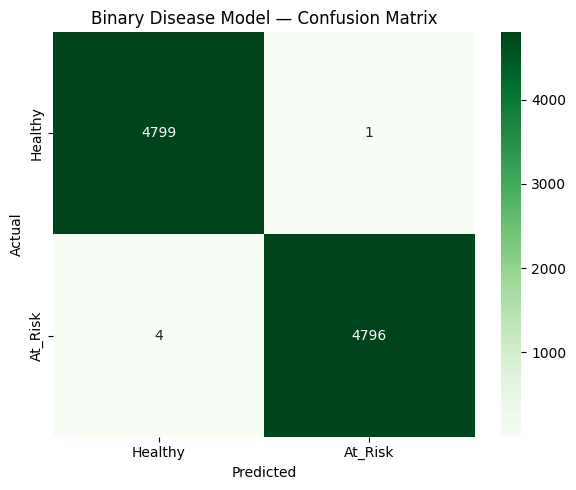

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'At_Risk'],
            yticklabels=['Healthy', 'At_Risk'], ax=ax)
ax.set_title('Binary Disease Model — Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 6 — Save Models
Same filenames as before — `app.py` needs no changes.

In [9]:
os.makedirs('../backend/models', exist_ok=True)

# Binary label encoder — 0=Healthy, 1=At_Risk
binary_le = LabelEncoder()
binary_le.classes_ = np.array(['Healthy', 'At_Risk'])

assert binary_le.inverse_transform([0])[0] == 'Healthy'
assert binary_le.inverse_transform([1])[0] == 'At_Risk'
print('✅ binary_le verified: 0=Healthy, 1=At_Risk')

joblib.dump(model,     '../backend/models/crop_disease_model.pkl')
joblib.dump(binary_le, '../backend/models/disease_label_encoder.pkl')
joblib.dump(crop_le,   '../backend/models/crop_name_encoder.pkl')

# Save feature list so app.py can verify order
with open('../backend/models/disease_features.json', 'w') as f:
    import json
    json.dump(FEATURES, f)

print('\nSaved:')
print('  crop_disease_model.pkl      ← XGBoost binary classifier')
print('  disease_label_encoder.pkl   ← 0=Healthy, 1=At_Risk')
print('  crop_name_encoder.pkl       ← crop string → integer')
print('  disease_features.json       ← feature order reference')

✅ binary_le verified: 0=Healthy, 1=At_Risk

Saved:
  crop_disease_model.pkl      ← XGBoost binary classifier
  disease_label_encoder.pkl   ← 0=Healthy, 1=At_Risk
  crop_name_encoder.pkl       ← crop string → integer
  disease_features.json       ← feature order reference


## Step 7 — Update app.py predict_disease function
The new model uses XGBoost and has extra features (NP_ratio etc).
Replace the predict_disease function in app.py with the version below.

In [10]:
# ── Test inference ────────────────────────────────────────────────────────────
def predict(crop_name, N, P, K, temperature, humidity, rainfall, ph):
    crop_enc = crop_le.transform([crop_name])[0]
    feats = np.array([[
        N, P, K, temperature, humidity, rainfall, ph,
        crop_enc,
        N / (P + 1),           # NP_ratio
        N / (K + 1),           # NK_ratio
        temperature * humidity, # temp_humidity
        rainfall / (ph + 1)    # rain_ph
    ]])
    prob  = model.predict_proba(feats)[0]
    label = model.predict(feats)[0]
    return {
        'label'      : 'At_Risk' if label == 1 else 'Healthy',
        'atRiskProb' : round(float(prob[1]), 4),
        'healthyProb': round(float(prob[0]), 4)
    }

# Test scenarios
tests = [
    ('rice',   12,  9,  9,  25, 91, 315, 4.9, 'AT_RISK expected'),
    ('maize',  80, 50, 45,  25, 58, 130, 6.2, 'HEALTHY expected'),
    ('wheat',  15,  8,  8,   8, 85, 210, 5.0, 'AT_RISK expected'),
    ('cotton', 90, 50, 60,  28, 42,  80, 7.0, 'HEALTHY expected'),
    ('tomato',  8, 10, 10,  11, 88, 250, 4.5, 'AT_RISK expected'),
    ('banana', 80, 60, 40,  28, 65, 180, 6.0, 'HEALTHY expected'),
]

print('Inference test:')
for crop, N, P, K, temp, rh, rain, ph, note in tests:
    r = predict(crop, N, P, K, temp, rh, rain, ph)
    status = '✅' if (note.startswith('AT') and r['label']=='At_Risk') or \
                     (note.startswith('HE') and r['label']=='Healthy') else '❌'
    print(f'  {status} {crop:12} → {r["label"]:8} (risk={r["atRiskProb"]:.2f}) [{note}]')

Inference test:
  ✅ rice         → At_Risk  (risk=1.00) [AT_RISK expected]
  ✅ maize        → Healthy  (risk=0.00) [HEALTHY expected]
  ✅ wheat        → At_Risk  (risk=1.00) [AT_RISK expected]
  ✅ cotton       → Healthy  (risk=0.00) [HEALTHY expected]
  ✅ tomato       → At_Risk  (risk=1.00) [AT_RISK expected]
  ✅ banana       → Healthy  (risk=0.00) [HEALTHY expected]


## Step 8 — Update predict_disease in app.py
After saving the new pkl files, update the `predict_disease` function in `app.py`.
Replace it with this version which adds the 4 interaction features:

In [11]:
# Copy this function into app.py — replaces the existing predict_disease
new_predict_disease_code = '''
def predict_disease(sensor, config):
    crop = config.get("cropType", "").lower().strip()
    if crop not in DISEASE_CROPS:
        return {"label": "Not Available", "atRiskProb": None, "healthyProb": None,
                "reason": f"'{crop}' not supported.",
                "supported": sorted(DISEASE_CROPS.keys()),
                "timestamp": datetime.utcnow().isoformat()}

    crop_encoded = crop_name_le.transform([DISEASE_CROPS[crop]])[0]
    N = float(sensor["N"])
    P = float(sensor["P"])
    K = float(sensor["K"])
    temp = float(sensor["temperature"])
    rh   = float(sensor["humidity"])
    rain = float(sensor["rainfall"])
    ph   = float(sensor["ph"])

    X = pd.DataFrame([{
        "N": N, "P": P, "K": K,
        "temperature": temp, "humidity": rh,
        "rainfall": rain, "ph": ph,
        "crop_encoded": int(crop_encoded),
        "NP_ratio":      N / (P + 1),
        "NK_ratio":      N / (K + 1),
        "temp_humidity": temp * rh,
        "rain_ph":       rain / (ph + 1)
    }])

    prob  = disease_model.predict_proba(X)[0]
    label = disease_model.predict(X)[0]
    return {
        "label"      : "At_Risk" if label == 1 else "Healthy",
        "atRiskProb" : round(float(prob[1]), 4),
        "healthyProb": round(float(prob[0]), 4),
        "diseaseName": None,
        "timestamp"  : datetime.utcnow().isoformat()
    }
'''
print('Copy the function above into app.py to complete the upgrade.')
print('All other app.py code stays the same.')

Copy the function above into app.py to complete the upgrade.
All other app.py code stays the same.


In [12]:
print('=' * 55)
print('  KISAAN AI — Binary Disease Classifier v3')
print('=' * 55)
print(f'  Algorithm  : XGBoost (binary:logistic)')
print(f'  Crops      : {len(CROPS)}')
print(f'  Total rows : {len(df):,}')
print(f'  Accuracy   : {acc:.4f} ({acc*100:.1f}%)')
print(f'  ROC-AUC    : {roc_auc:.4f}')
print(f'  Features   : {len(FEATURES)}')
print('=' * 55)
print('  Files saved to backend/models/')
print('  app.py: update predict_disease with Step 8 code')
print('=' * 55)

  KISAAN AI — Binary Disease Classifier v3
  Algorithm  : XGBoost (binary:logistic)
  Crops      : 48
  Total rows : 48,000
  Accuracy   : 0.9995 (99.9%)
  ROC-AUC    : 1.0000
  Features   : 12
  Files saved to backend/models/
  app.py: update predict_disease with Step 8 code
